In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("../data/raw/application_train.csv")


SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE                str
CODE_GENDER                       str
FLAG_OWN_CAR                      str
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object


In [15]:
print(df.shape)
print(df.info())
df.head()

(307511, 122)
<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB
None


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Default Count vs Not Default Count')

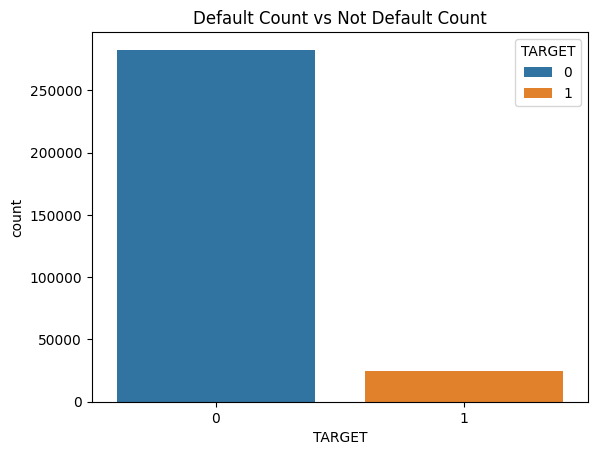

In [16]:
print(df['TARGET'].value_counts(normalize=True))
sns.countplot(df, x= 'TARGET', hue= 'TARGET')
plt.title('Default Count vs Not Default Count')


- Heavy class imbalance, so accuracy is not going to be a good measure
- prioritize precision, recall, f1, and ROC-AUC
- class weight set to balanced


In [17]:
#find columns with missing values by proportion
missing_prop = df.isna().mean().sort_values(ascending=False)
#narrow down to all columns with missing values
missing_prop = missing_prop[missing_prop >0]

#more than 50% of columns missing
missing_prop_50 = missing_prop[missing_prop > 0.5].round(3)
#between 10% and 50% of column missing

missing_prop_10_50 = missing_prop[(missing_prop >0.1) & (missing_prop < 0.5)]

missing_prop_under_10 = missing_prop[missing_prop < 0.1].round(4)

print(missing_prop_50)



COMMONAREA_AVG              0.699
COMMONAREA_MODE             0.699
COMMONAREA_MEDI             0.699
NONLIVINGAPARTMENTS_MEDI    0.694
NONLIVINGAPARTMENTS_MODE    0.694
NONLIVINGAPARTMENTS_AVG     0.694
FONDKAPREMONT_MODE          0.684
LIVINGAPARTMENTS_AVG        0.684
LIVINGAPARTMENTS_MEDI       0.684
LIVINGAPARTMENTS_MODE       0.684
FLOORSMIN_MODE              0.678
FLOORSMIN_AVG               0.678
FLOORSMIN_MEDI              0.678
YEARS_BUILD_AVG             0.665
YEARS_BUILD_MODE            0.665
YEARS_BUILD_MEDI            0.665
OWN_CAR_AGE                 0.660
LANDAREA_MEDI               0.594
LANDAREA_AVG                0.594
LANDAREA_MODE               0.594
BASEMENTAREA_MODE           0.585
BASEMENTAREA_MEDI           0.585
BASEMENTAREA_AVG            0.585
EXT_SOURCE_1                0.564
NONLIVINGAREA_MODE          0.552
NONLIVINGAREA_AVG           0.552
NONLIVINGAREA_MEDI          0.552
ELEVATORS_AVG               0.533
ELEVATORS_MEDI              0.533
ELEVATORS_MODE

In [18]:
print(missing_prop_10_50.round(3))

FLOORSMAX_MODE                  0.498
FLOORSMAX_AVG                   0.498
FLOORSMAX_MEDI                  0.498
YEARS_BEGINEXPLUATATION_MODE    0.488
YEARS_BEGINEXPLUATATION_MEDI    0.488
YEARS_BEGINEXPLUATATION_AVG     0.488
TOTALAREA_MODE                  0.483
EMERGENCYSTATE_MODE             0.474
OCCUPATION_TYPE                 0.313
EXT_SOURCE_3                    0.198
AMT_REQ_CREDIT_BUREAU_HOUR      0.135
AMT_REQ_CREDIT_BUREAU_WEEK      0.135
AMT_REQ_CREDIT_BUREAU_MON       0.135
AMT_REQ_CREDIT_BUREAU_YEAR      0.135
AMT_REQ_CREDIT_BUREAU_DAY       0.135
AMT_REQ_CREDIT_BUREAU_QRT       0.135
dtype: float64


In [19]:
print(missing_prop_under_10)

NAME_TYPE_SUITE             0.0042
DEF_60_CNT_SOCIAL_CIRCLE    0.0033
OBS_60_CNT_SOCIAL_CIRCLE    0.0033
DEF_30_CNT_SOCIAL_CIRCLE    0.0033
OBS_30_CNT_SOCIAL_CIRCLE    0.0033
EXT_SOURCE_2                0.0021
AMT_GOODS_PRICE             0.0009
AMT_ANNUITY                 0.0000
CNT_FAM_MEMBERS             0.0000
DAYS_LAST_PHONE_CHANGE      0.0000
dtype: float64


### Missing value observations

- many columns seem to come in groups of mode, median, average for the same thing, and each set of mode, median, average has the same prop of missing values
     - highly redundant, and probably will drop all of these due to high missing percentage
- most columns with missing proportion over 50% are related to housing, except for EXT_SOURCE_1 and OWN_CAR_AGE, need to investigate these columns more
     - also a FLAG_OWN_CAR column, likely related with OWN_CAR_AGE
- columns just below 50% missing are also housing related, probably drop
- all AMT columns have same missing prop (0.135), same rows with missing values, can probably impute with median or mean depending on skewness
- occupation type is likely an important indicator (higher paying occupation, less likely to default), missing value could mean unemployed


### Will drop these columns for now to make looking at the rest of the dataset easier since there are so many columns

- all preprocessing will be done later in a pipeline so that data is not leaked






In [20]:
#0.48 is the missing prop for total_area_mode, last housing related column

cols_to_drop = [col for col in df.columns if df[col].isna().mean() > 0.48] 
cols_to_drop.remove('OWN_CAR_AGE')
cols_to_drop.remove('EXT_SOURCE_1')



count    134133.000000
mean          0.502130
std           0.211062
min           0.014568
25%           0.334007
50%           0.505998
75%           0.675053
max           0.962693
Name: EXT_SOURCE_1, dtype: float64
count    104582.000000
mean         12.061091
std          11.944812
min           0.000000
25%           5.000000
50%           9.000000
75%          15.000000
max          91.000000
Name: OWN_CAR_AGE, dtype: float64
0.66
FLAG_OWN_CAR
N    0.66
Y    0.34
Name: proportion, dtype: float64


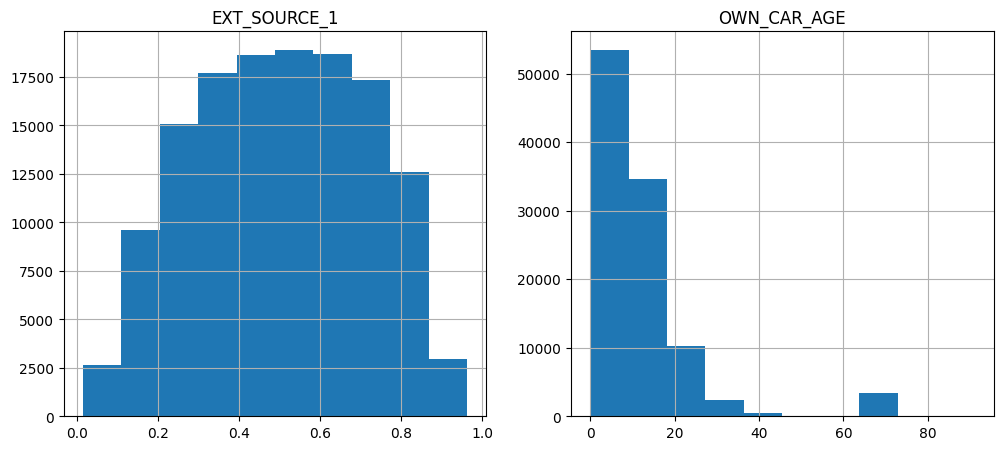

In [21]:
# look more in depth at EXT_SOURCE_1 and OWN_CAR_AGE

print(df['EXT_SOURCE_1'].describe())
print(df['OWN_CAR_AGE'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# EXT_SOURCE_1 histogram
df['EXT_SOURCE_1'].hist(ax=axes[0])
axes[0].set_title('EXT_SOURCE_1')

# OWN_CAR_AGE histogram
df['OWN_CAR_AGE'].hist(ax=axes[1])
axes[1].set_title('OWN_CAR_AGE')


print(df['OWN_CAR_AGE'].isna().mean().round(3))
print(df['FLAG_OWN_CAR'].value_counts(normalize=True).round(3))



- EXT_SOURCE_ONE normally distributed, OWN_CAR_AGE is right skewed
    - not sure what to do with EXT_SOURCE_1 yet, will look at correlation with target later in the notebook

- OWN_CAR_AGE is missing 66% of values and in the FLAG_OWN_CAR column, 66% of the values are 'no'.  Seems to be redundant, will drop FLAG_OWN_CAR and keep OWN_CAR_AGE, imputing missing 
values with 0

In [22]:
cols_to_drop.append('FLAG_OWN_CAR')
df.drop(columns = cols_to_drop, inplace= True, errors= 'ignore')

df.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,Y,0,202500.0,406597.5,24700.5,351000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,0,270000.0,1293502.5,35698.5,1129500.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,0,67500.0,135000.0,6750.0,135000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,Y,0,135000.0,312682.5,29686.5,297000.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,Y,0,121500.0,513000.0,21865.5,513000.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
num_df= df.select_dtypes(include = 'number')
cat_df = df.select_dtypes(include = 'object')

missing_num_cols = num_df.isna().mean().sort_values(ascending=False) 
missing_num_cols = missing_num_cols[missing_num_cols > 0.01]
print(missing_num_cols.round(3))

missing_cat_cols = cat_df.isna().mean().sort_values(ascending=False) 
missing_cat_cols = missing_cat_cols[missing_cat_cols > 0]
print(missing_cat_cols.round(3))


print(df['EMERGENCYSTATE_MODE'].value_counts(normalize=True))

#drop EMERGENCYSTATE_MODE, high prop of missing values and 99% of remaining values are 'no'

df = df.drop(columns = 'EMERGENCYSTATE_MODE', errors = 'ignore')

OWN_CAR_AGE                   0.660
EXT_SOURCE_1                  0.564
EXT_SOURCE_3                  0.198
AMT_REQ_CREDIT_BUREAU_HOUR    0.135
AMT_REQ_CREDIT_BUREAU_DAY     0.135
AMT_REQ_CREDIT_BUREAU_YEAR    0.135
AMT_REQ_CREDIT_BUREAU_QRT     0.135
AMT_REQ_CREDIT_BUREAU_WEEK    0.135
AMT_REQ_CREDIT_BUREAU_MON     0.135
dtype: float64
EMERGENCYSTATE_MODE    0.474
OCCUPATION_TYPE        0.313
NAME_TYPE_SUITE        0.004
dtype: float64
EMERGENCYSTATE_MODE
No     0.985608
Yes    0.014392
Name: proportion, dtype: float64


### Imputation strategy

- Numerical columns: impute with median, unless stated otherwise (like for OWN_CAR_AGE, imputing with 0)
- Categorical columns: most frequent imputation (mode)

In [39]:
cat_cols = list(cat_df.columns)
cat_cols.remove('EMERGENCYSTATE_MODE')
for col in cat_cols:
    value_counts = df[col].value_counts(normalize=True).round(4)
    target_mean = df.groupby(col)['TARGET'].mean().round(4)

    summary = pd.concat([value_counts, target_mean], axis=1)
    summary.columns = ['proportion', 'target_mean']

    
    print(summary)

                    proportion  target_mean
NAME_CONTRACT_TYPE                         
Cash loans              0.9048       0.0835
Revolving loans         0.0952       0.0548
             proportion  target_mean
CODE_GENDER                         
F                0.6583       0.0700
M                0.3416       0.1014
XNA              0.0000       0.0000
                 proportion  target_mean
FLAG_OWN_REALTY                         
Y                    0.6937       0.0796
N                    0.3063       0.0832
                 proportion  target_mean
NAME_TYPE_SUITE                         
Unaccompanied        0.8116       0.0818
Family               0.1311       0.0749
Spouse, partner      0.0371       0.0787
Children             0.0107       0.0738
Other_B              0.0058       0.0983
Other_A              0.0028       0.0878
Group of people      0.0009       0.0849
                      proportion  target_mean
NAME_INCOME_TYPE                             
Working       

- **NAME_CONTRACT_TYPE**
    - 90% of applications on cash loans
    - keep, cash loans have higher default rate, one hot encode

- **CODE_GENDER**
    - 66% female, males also show a higher default rate
    -one hot encode
- **FlAG_OWN_REALTY**
    - 69% owners, no significant difference in default rate
    - keep for now, probably low predictive importance, one hot encode
- **NAME_TYPE_SUITE**
    - 81% unaccompanied, similar default rate accross groups
    - keep for now, probably low predictive importance
- **NAME_INCOME_TYPE**
    - unemployed is extremely high default risk (36%), maternity is extremely high default risk (40%)
    - keep
- **NAME_EDUCATION_TYPE**
    -lower education level seems to correlate with higher default risk
    -keep, seems to be a pattern
- **NAME_FAMILY_STATUS**
  - Married individuals (7.6%) have lower default rates than single or civil marriage (9.8%)
  -  keep, indicator of household stability

- **NAME_HOUSING_TYPE**
  - Renters (12.3%) and those living with parents (11.7%) have higher default rates than homeowners (7.8%).
  - keep

- **OCCUPATION_TYPE** 
  - Strong variation across categories:
    - Low-skill laborers, 17.1% default rate
    - managers/accountants are lower risk
  - keep, but will have to group the less common categories together, too many different categories in this column makes it hard to one hot encode as it is

- **WEEKDAY_APPR_PROCESS_START**
  - drop this column, default rates identical accross all days of the week

- **ORGANIZATION_TYPE**
  - keep for now but group less common categories
  -- might have to drop if there is low predictive power
 

In [25]:
print(num_df.columns)


Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL',
       'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT',
       'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START',
       'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION',
       'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'OBS_30_CNT_SOCIAL_CIRCLE',
       'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
       'DEF_60_CNT_SOCIAL_CIRCLE', 'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_2',
       'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5',
       'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', '

- Too many numerical columns to view summary stats/distributions all at once, see which ones are of importance
    - most of the columns fit into groups, ex. AMT_REQ_CREDIT_BUREAU, DAYS, FLAG, EXT_SOURCE, REG
    - will look at these columns together, as they might have similar anomalies
- don't need to look at distribution of SK_ID_CURR or TARGET
- don't need to look at any FLAG columns, since they are binary


In [26]:


days_cols = [col for col in num_df.columns if col.startswith('DAYS') ]
reg_cols = [col for col in num_df.columns if col.startswith('REG') ]
reg_cols.extend(['LIVE_REGION_NOT_WORK_REGION', 'LIVE_CITY_NOT_WORK_CITY' ])

ext_source_cols = [col for col in num_df.columns if col.startswith('EXT_SOURCE') ]
amt_cols = [col for col in num_df.columns if col.startswith('AMT') ]
days_cols = [col for col in num_df.columns if col.startswith('DAYS') ]
social_circle_cols = [col for col in num_df.columns if col.endswith('SOCIAL_CIRCLE') ]

cols_list = [days_cols, reg_cols, ext_source_cols, amt_cols, social_circle_cols, 'CNT_CHILDREN']

for lst in cols_list:
    
    print(df[lst].describe().round(3))

       DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  \
count  307511.000     307511.000         307511.000       307511.000   
mean   -16036.995      63815.046          -4986.120        -2994.202   
std      4363.989     141275.767           3522.886         1509.450   
min    -25229.000     -17912.000         -24672.000        -7197.000   
25%    -19682.000      -2760.000          -7479.500        -4299.000   
50%    -15750.000      -1213.000          -4504.000        -3254.000   
75%    -12413.000       -289.000          -2010.000        -1720.000   
max     -7489.000     365243.000              0.000            0.000   

       DAYS_LAST_PHONE_CHANGE  
count              307510.000  
mean                 -962.859  
std                   826.808  
min                 -4292.000  
25%                 -1570.000  
50%                  -757.000  
75%                  -274.000  
max                     0.000  
       REGION_POPULATION_RELATIVE  REGION_RATING_CLIENT  \
coun

55374


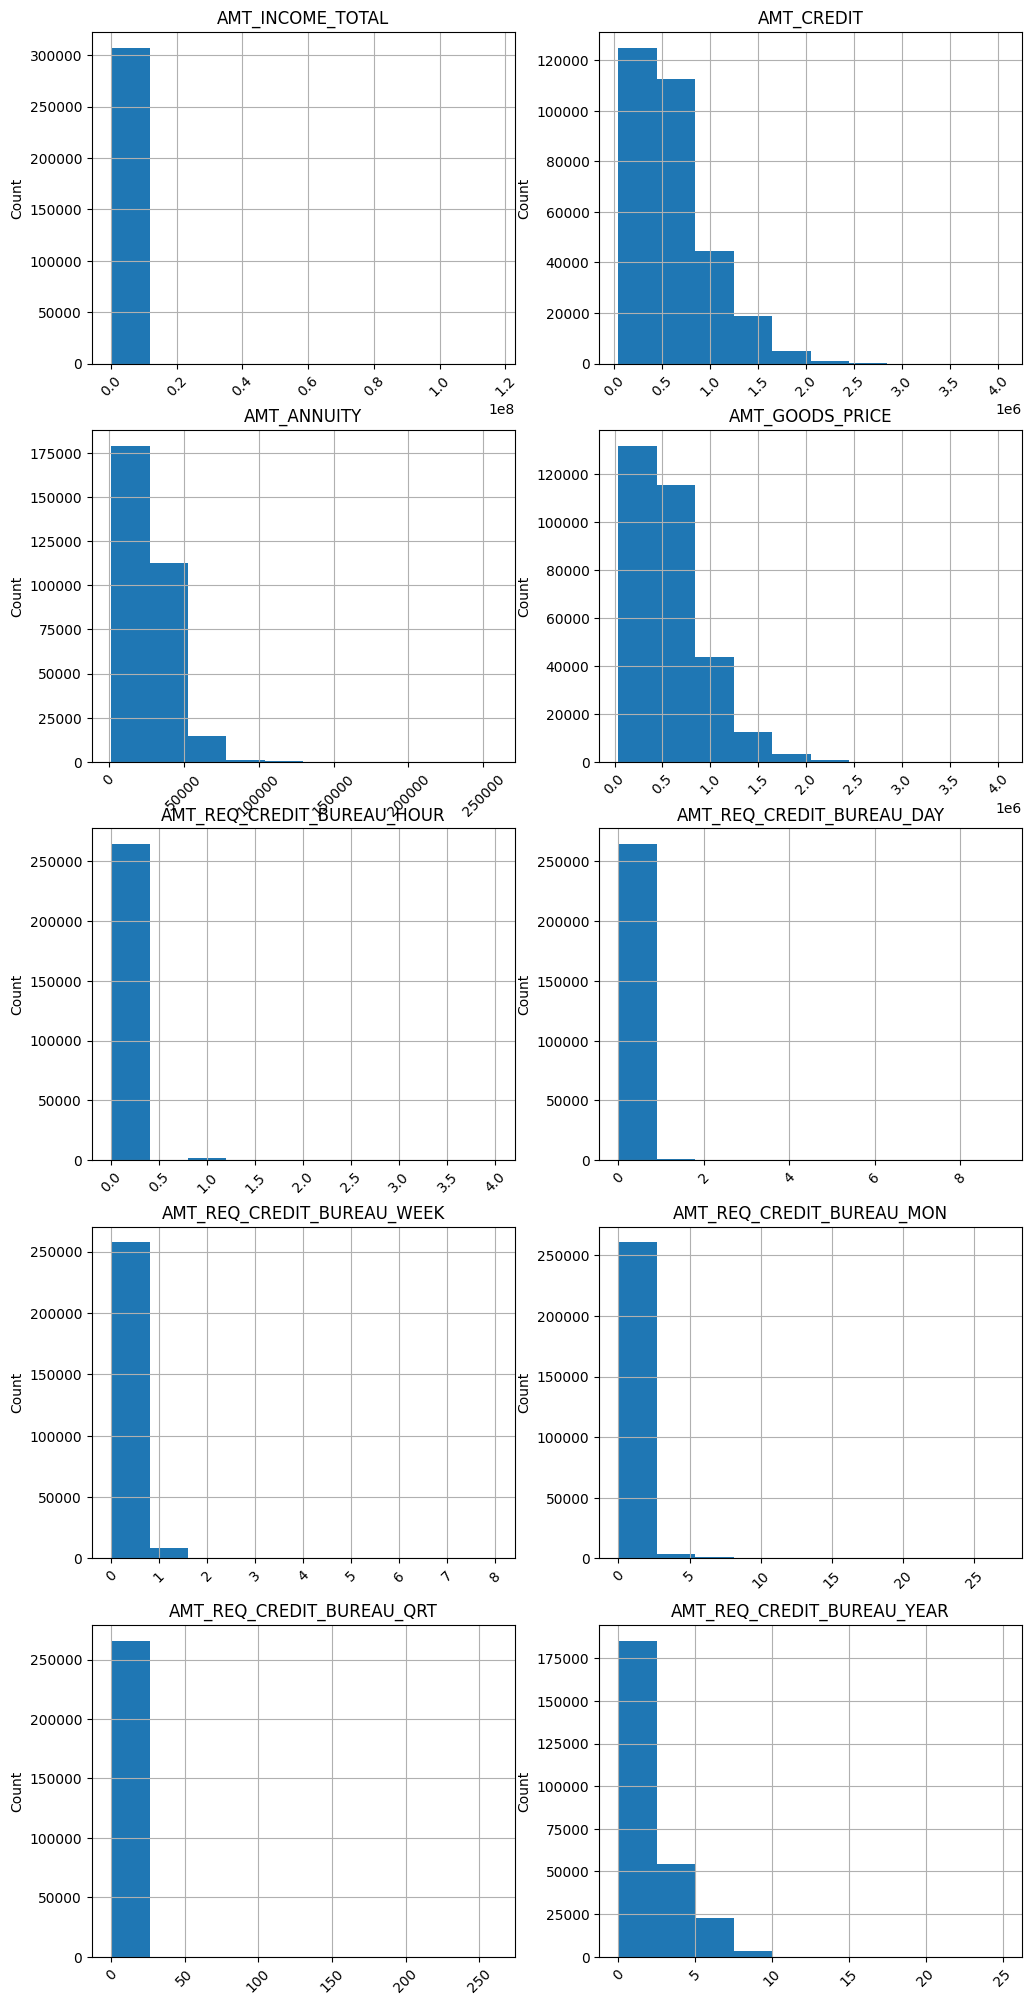

In [27]:
print((df['DAYS_EMPLOYED'] == 365243).sum())

fig, axes = plt.subplots( len(amt_cols)//2 , 2, figsize=(12, 5 * len(amt_cols)//2))

axes = axes.flatten()  # make indexing easy

for i, col in enumerate(amt_cols):
    num_df[col].hist(ax=axes[i])
    axes[i].set_title(f'{col}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)



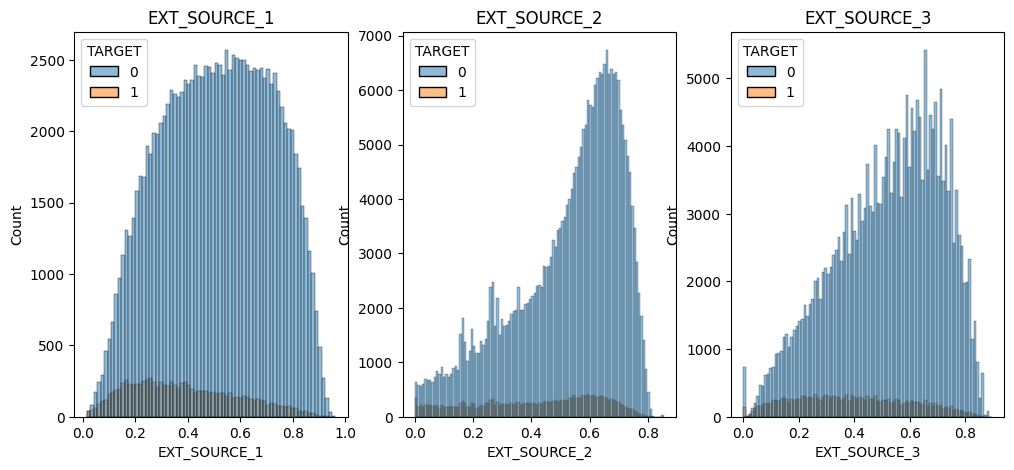

In [28]:
import math


fig, axes = plt.subplots(1, 3, figsize=(12, 5))
axes = axes.flatten()

for i, col in enumerate(ext_source_cols):
    sns.histplot(num_df, x = col, hue='TARGET', ax = axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

- DAYS columns are all negative
    - convert DAYS_BIRTH to age in years, and convert rest to positive values
    - DAYS_EMPLOYED has max of 365243, and that value appears 55,374 times, further research on kaggle dataset page indicates this is a marker for unemployed or retired
- AMT
    - Income is heavily skewed right, median of 147,000 and max of 117,000
    - AMT_CREDIT and AMT_GOODS_PRICE have very similar distributions, loans are probably close to the price of what is being purchased
- SOCIAL_CIRCLE
    - most columns skewed right, mean way higher than median
- CNT_CHILDREN 
    - skewed right
- EXT_SOURCE
    - EXT_SOURCE_1 is normally distributed for no default, and slightly skewed right for default, source 2 and source 3 are skewed right for both default and non default
    - flag column for EXT_SOURCE_1, indicate if it is missing or not since it is an important indicator and doesn't have any other clear imputation strategy
    - EXT_SOURCE_3 also has 19% of values missing, also make a flag column

In [29]:
credit_and_goods_price_corr = df['AMT_CREDIT'].corr(df['AMT_GOODS_PRICE'])
credit_and_goods_price_corr.round(3)


np.float64(0.987)

<Figure size 640x480 with 0 Axes>

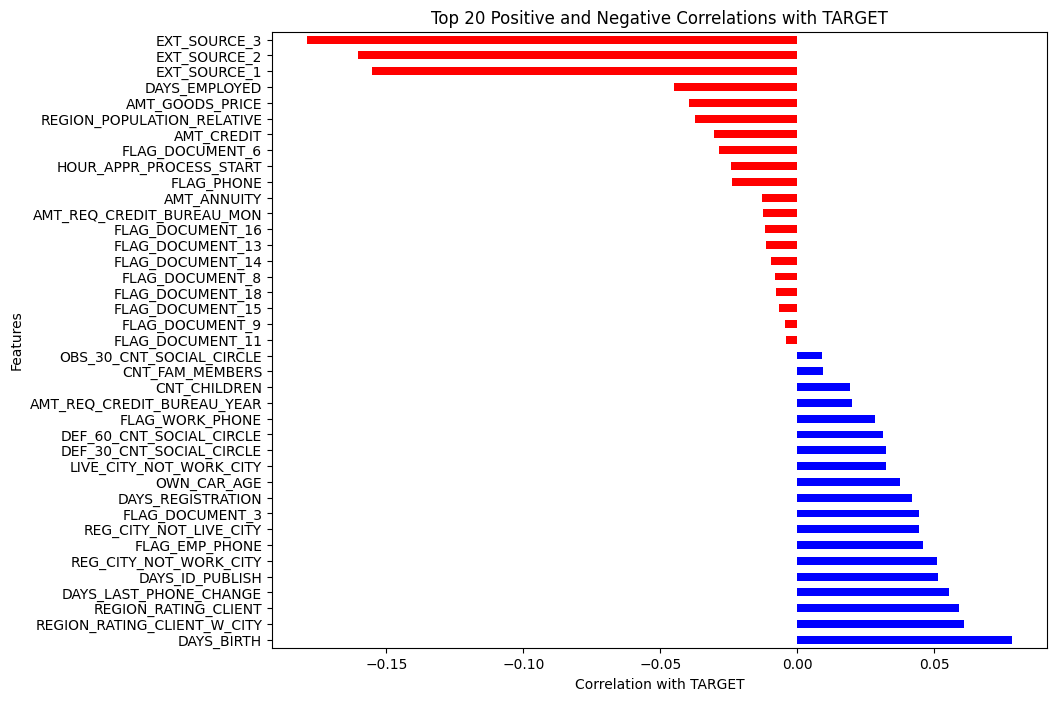

DAYS_BIRTH                     0.078
REGION_RATING_CLIENT_W_CITY    0.061
REGION_RATING_CLIENT           0.059
DAYS_LAST_PHONE_CHANGE         0.055
DAYS_ID_PUBLISH                0.051
REG_CITY_NOT_WORK_CITY         0.051
FLAG_EMP_PHONE                 0.046
REG_CITY_NOT_LIVE_CITY         0.044
FLAG_DOCUMENT_3                0.044
DAYS_REGISTRATION              0.042
OWN_CAR_AGE                    0.038
LIVE_CITY_NOT_WORK_CITY        0.033
DEF_30_CNT_SOCIAL_CIRCLE       0.032
DEF_60_CNT_SOCIAL_CIRCLE       0.031
FLAG_WORK_PHONE                0.029
AMT_REQ_CREDIT_BUREAU_YEAR     0.020
CNT_CHILDREN                   0.019
CNT_FAM_MEMBERS                0.009
OBS_30_CNT_SOCIAL_CIRCLE       0.009
FLAG_DOCUMENT_11              -0.004
FLAG_DOCUMENT_9               -0.004
FLAG_DOCUMENT_15              -0.007
FLAG_DOCUMENT_18              -0.008
FLAG_DOCUMENT_8               -0.008
FLAG_DOCUMENT_14              -0.009
FLAG_DOCUMENT_13              -0.012
FLAG_DOCUMENT_16              -0.012
A

In [30]:
correlation_w_target = (num_df.corr()['TARGET']).sort_values(ascending = False)

top_corrs = pd.concat([correlation_w_target.head(20), correlation_w_target.tail(20)])
top_corrs.drop('TARGET', inplace=True)
plt.figure()
plt.figure(figsize=(10, 8))
#red for negative
color = ['red' if feature < 0 else 'blue' for feature in top_corrs ]

top_corrs.plot(kind= 'barh', color = color)
plt.title('Top 20 Positive and Negative Correlations with TARGET')
plt.xlabel('Correlation with TARGET')
plt.ylabel('Features')
plt.show()

print(top_corrs.round(3))

KeyboardInterrupt: 

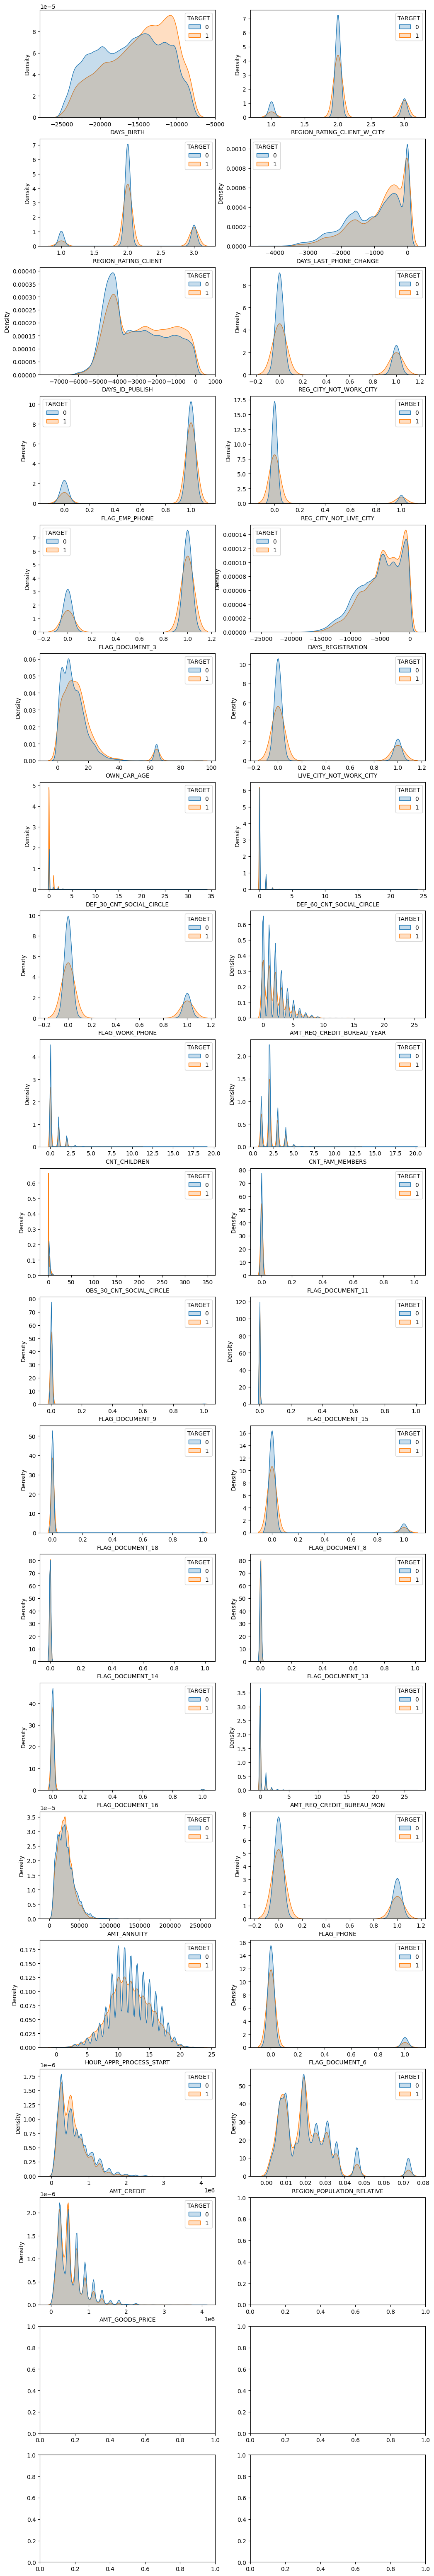

In [31]:
cols = list(top_corrs.index)


n_rows = math.ceil(len(cols) / 2)

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.kdeplot(data=num_df,x=col,hue='TARGET',fill=True,common_norm=False,ax=axes[i])


- Aside from external source columns, distributions between Target=0 and Target=1 are almost the same
    - matches up with correlation results, these columns have the most predictive power

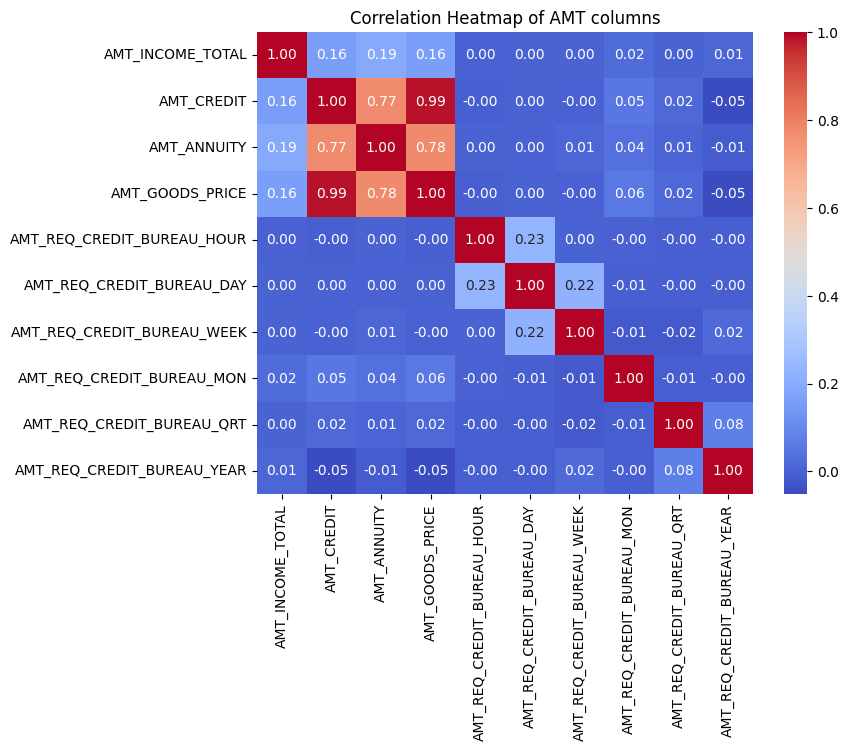

In [33]:
amt_df = df[amt_cols]

amt_corr = amt_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(amt_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of AMT columns")
plt.show()

       DAYS_BIRTH  DAYS_EMPLOYED  DAYS_REGISTRATION  DAYS_ID_PUBLISH  \
count   307511.00      307511.00          307511.00        307511.00   
mean    -16037.00       63815.05           -4986.12         -2994.20   
std       4363.99      141275.77            3522.89          1509.45   
min     -25229.00      -17912.00          -24672.00         -7197.00   
25%     -19682.00       -2760.00           -7479.50         -4299.00   
50%     -15750.00       -1213.00           -4504.00         -3254.00   
75%     -12413.00        -289.00           -2010.00         -1720.00   
max      -7489.00      365243.00               0.00             0.00   

       DAYS_LAST_PHONE_CHANGE  
count               307510.00  
mean                  -962.86  
std                    826.81  
min                  -4292.00  
25%                  -1570.00  
50%                   -757.00  
75%                   -274.00  
max                      0.00  


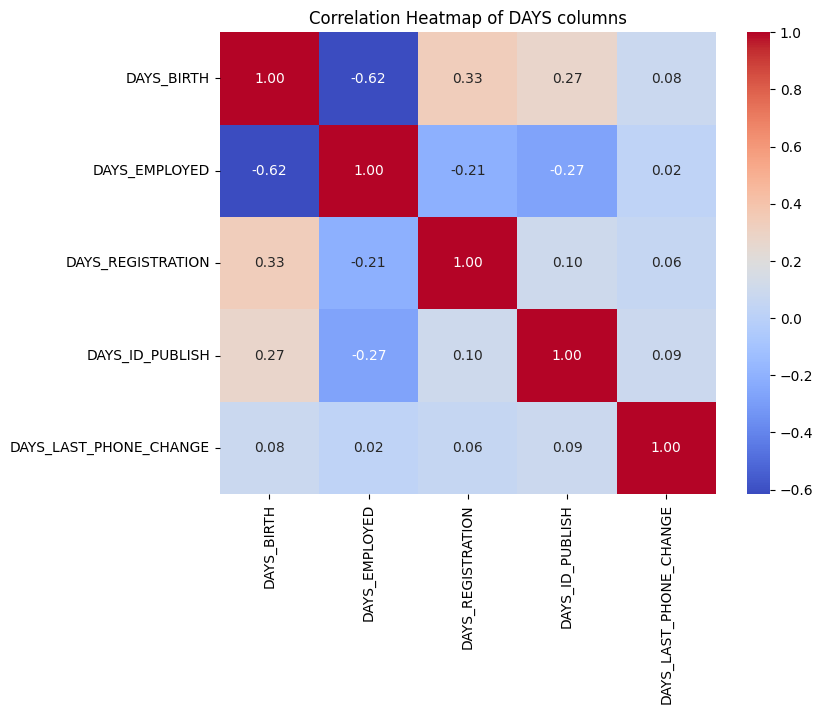

In [38]:
days_df = df[days_cols]

print(days_df.describe().round(2))

days_corr = days_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(days_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of DAYS columns")
plt.show()

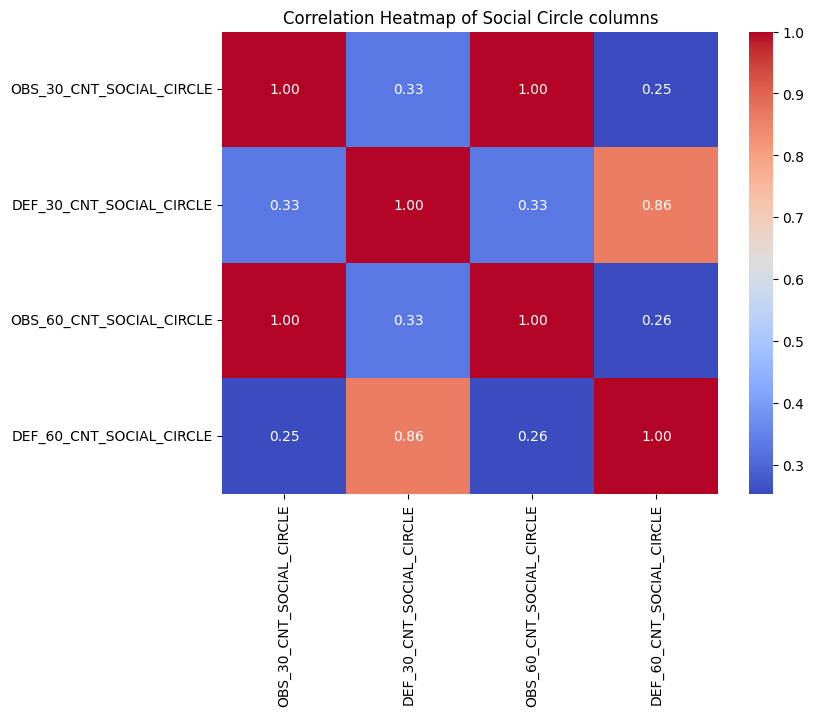

In [35]:
social_df = df[social_circle_cols]

social_corr = social_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(social_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Social Circle columns")
plt.show()

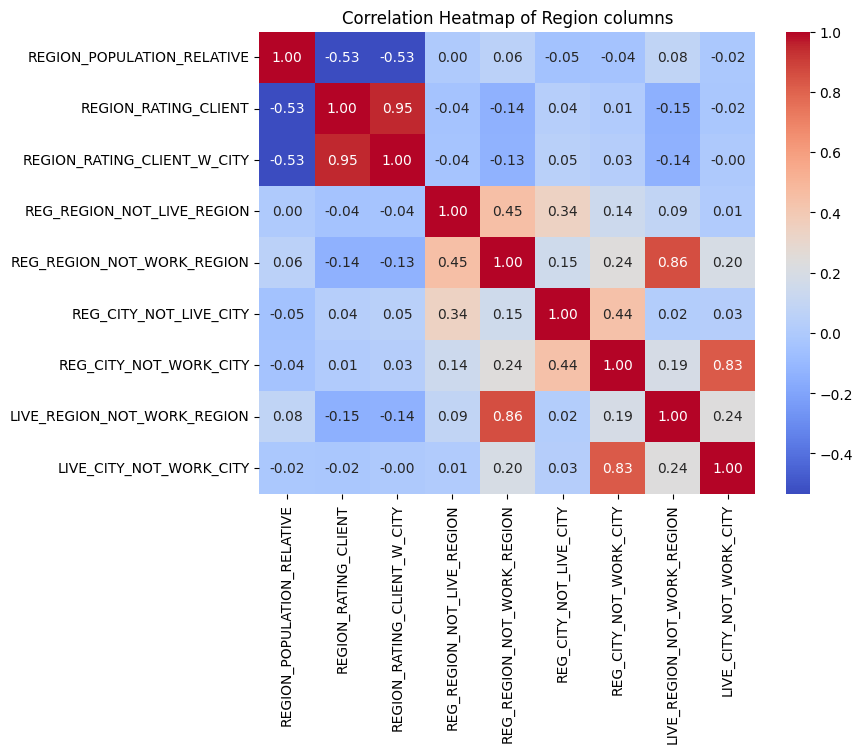

In [36]:
reg_df = df[reg_cols]

reg_corr = reg_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(reg_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Region columns")
plt.show()

## Final Preprocessing Decisions

### Columns to Drop
- High missingness (>48%) housing-related columns: Dropped, hard to impute and sparse
- FLAG_OWN_CAR: Dropped, redundant with OWN_CAR_AGE (missingness pattern identical, 66% no-car in both).
- EMERGENCYSTATE_MODE: Dropped, 50% missing and 99% of remaining values are "No" (near-zero variance).
- WEEKDAY_APPR_PROCESS_START: Dropped, default rate is identical across all days of the week, no predictive signal.

### Missing Value Imputation (to be done in pipeline, no data leakage from training to test)
- OWN_CAR_AGE: impute with 0
- impute other missing numerical values with median
- categorical columns impute with mode

### Handling Anomalies
- DAYS_EMPLOYED = 365243: placeholder value for unemployed/retired (appears 55,374 times). Replace with NaN before imputing with median. make a flag column indicating whether or not they are employed
- DAYS_BIRTH: Convert to age in years, AGE_YEARS = -DAYS_BIRTH / 365.
- All other DAYS columns: Convert to positive values by multiplying by -1.

### Categorical Encoding
- One-hot encode: NAME_CONTRACT_TYPE, CODE_GENDER, FLAG_OWN_REALTY, NAME_TYPE_SUITE, NAME_INCOME_TYPE, NAME_EDUCATION_TYPE, NAME_FAMILY_STATUS, NAME_HOUSING_TYPE.
- Group rare categories before encoding: OCCUPATION_TYPE and ORGANIZATION_TYPE, group less common categories into "other" before encoding

### Feature Notes
- EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3: Strongest predictors of default, highest absolute correlation with target. Keep all three; impute all with median.  and create flag for 
EXT_SOURCE_1 and EXT_SOURCE_3
- Skewed AMT columns(AMT_INCOME_TOTAL): Apply log transform before modeling, only really matters for linear models
- CNT_CHILDREN Social circle columns: Right-skewed; consider capping outliers at a very high percentile, ex. 99%

# Handling collinearity

#### AMT Columns
- AMT_CREDIT / AMT_GOODS_PRICE (0.98 correlation): create CREDIT_TO_GOODS_RATIO: AMT_CREDIT / AMT_GOODS_PRICE  captures overborrowing relative to purchase price as a risk signal. Drop AMT_GOODS_PRICE, keep AMT_CREDIT for now.
- AMT_ANNUITY (0.77 correlation with AMT_CREDIT and AMT_GOODS_PRICE): create ANNUITY_TO_INCOME_RATIO: AMT_ANNUITY / AMT_INCOME_TOTAL Drop raw AMT_ANNUITY after new column created.

#### Social Circle Columns
- DEF_30_CNT_SOCIAL_CIRCLE / DEF_60_CNT_SOCIAL_CIRCLE (0.66 correlation): Keep both for now
#### Region Columns
- REGION_RATING_CLIENT / REGION_RATING_CLIENT_W_CITY (0.95 correlation): Drop REGION_RATING_CLIENT, keep REGION_RATING_CLIENT_W_CITY
- REG_REGION_NOT_WORK_REGION / LIVE_REGION_NOT_WORK_REGION (0.86 correlation): Drop REG_REGION_NOT_WORK_REGION, keep LIVE_REGION_NOT_WORK_REGION.  Living region more important than registered region.
- REG_CITY_NOT_WORK_CITY / LIVE_CITY_NOT_WORK_CITY (0.83 correlation): Drop REG_CITY_NOT_WORK_CITY, keep LIVE_CITY_NOT_WORK_CITY.  Living region more important than registered region.

### Class Imbalance
- Target is heavily imbalanced (92% non default). 
- Use class_weight='balanced' in models, and evaluate with Precision, Recall, F1, and ROC-AUC.
- Consider oversampling (SMOTE) or undersampling as an alternative strategy during modeling.


